In [1]:
model_id = 'sherlock'

In [2]:
%env PYTHONHASHSEED=13
%env PYTHONHASHSEED

env: PYTHONHASHSEED=13


'13'

In [3]:
from pandas.core.arrays.integer import dtype
%load_ext autoreload
%autoreload 2

In [4]:
import itertools

from ast import literal_eval
from collections import Counter
from datetime import datetime

import pandas as pd
import numpy as np

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
#from sklearn.ensemble import ExtraTreesClassifier,
#from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import classification_report, f1_score

### Train

In [6]:
data_dir = "../custom_data"

In [7]:
X_train = pd.read_parquet(f"{data_dir}/processed/train.parquet")
y_train = pd.read_parquet(f"{data_dir}/raw/train_labels.parquet").values.flatten()

y_train = np.array([x.lower() for x in y_train])

### Validation

In [8]:
X_validation = pd.read_parquet(f"{data_dir}/processed/validation.parquet")
y_validation = pd.read_parquet(f"{data_dir}/raw/validation_labels.parquet").values.flatten()

y_validation = np.array([x.lower() for x in y_validation])

### Testing

In [9]:
X_test = pd.read_parquet(f"{data_dir}/processed/test.parquet")
y_test = pd.read_parquet(f"{data_dir}/raw/test_labels.parquet").values.flatten()

y_test = np.array([x.lower() for x in y_test])

### Contact train and val

In [10]:
X_train = pd.concat([X_train, X_validation], ignore_index=True)
y_train = np.array([x.lower() for x in itertools.chain(y_train, y_validation)])

### Train Voting Classifier using RFC and ETC

In [11]:
# n_estimators=300 gives a slightly better result (0.1%), but triples the fit time
voting_clf = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=13, n_jobs=-1)),
        ('et', ExtraTreesClassifier(n_estimators=100, random_state=13, n_jobs=-1))
    ],
    voting='soft'
)

start = datetime.now()
print(f'Started at {start}')

# label encoder
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)

# train model
voting_clf.fit(X_train, y_train_enc)

print(f'Finished at {datetime.now()}, took {datetime.now() - start} seconds')

Started at 2025-05-25 14:58:17.921411
Finished at 2025-05-25 14:58:19.122118, took 0:00:01.200727 seconds


In [12]:
# Make individual (trained) estimators available
rf_clf = voting_clf.estimators_[0]
et_clf = voting_clf.estimators_[1]

## Make predictions

In [13]:
def predicted_labels(y_pred_proba, encoder):
    y_pred_int = y_pred_proba.argmax(axis=1)
    return encoder.inverse_transform(y_pred_int)

### Predict: RFC

In [14]:
pred_rfs_prob = predicted_labels(rf_clf.predict_proba(X_test), le)
print("F1 (weighted):", f1_score(y_test, pred_rfs_prob, average="weighted"))

F1 (weighted): 0.7763832785967563


In [15]:
print(classification_report(y_test, pred_rfs_prob, zero_division=0))

                        precision    recall  f1-score   support

                   age       0.67      0.80      0.73         5
           case_status       0.80      0.80      0.80         5
       contact_setting       0.00      0.00      0.00         2
                  date       0.96      0.96      0.96        24
                gender       0.60      0.75      0.67         4
                    id       1.00      0.90      0.95        10
              location       0.90      0.82      0.86        11
       medical_boolean       0.36      0.36      0.36        11
            occupation       0.50      0.50      0.50         2
               outcome       1.00      0.75      0.86         4
pre_existing_condition       0.33      0.25      0.29         4
              symptoms       0.79      0.92      0.85        25

              accuracy                           0.79       107
             macro avg       0.66      0.65      0.65       107
          weighted avg       0.77     

### Predict: ETC

In [16]:
pred_etc_prob = predicted_labels(et_clf.predict_proba(X_test), le)
print("F1 (weighted):", f1_score(y_test, pred_etc_prob, average="weighted"))

F1 (weighted): 0.79052778552111


In [17]:
print(classification_report(y_test, pred_etc_prob, zero_division=0))

                        precision    recall  f1-score   support

                   age       0.80      0.80      0.80         5
           case_status       0.71      1.00      0.83         5
       contact_setting       0.00      0.00      0.00         2
                  date       0.92      0.96      0.94        24
                gender       1.00      0.75      0.86         4
                    id       1.00      1.00      1.00        10
              location       0.69      0.82      0.75        11
       medical_boolean       0.40      0.36      0.38        11
            occupation       1.00      0.50      0.67         2
               outcome       1.00      0.75      0.86         4
pre_existing_condition       0.33      0.25      0.29         4
              symptoms       0.85      0.92      0.88        25

              accuracy                           0.80       107
             macro avg       0.73      0.68      0.69       107
          weighted avg       0.79     

### Predict: Voting Classifier (RFC + ETC)

In [18]:
pred_voting_prob = predicted_labels(voting_clf.predict_proba(X_test), le)
print("F1 (weighted):", f1_score(y_test, pred_voting_prob, average="weighted"))

F1 (weighted): 0.7898937511087044


In [19]:
predicted_rfc_proba = rf_clf.predict_proba(X_test)

In [20]:
print(classification_report(y_test, pred_etc_prob, zero_division=0))

                        precision    recall  f1-score   support

                   age       0.80      0.80      0.80         5
           case_status       0.71      1.00      0.83         5
       contact_setting       0.00      0.00      0.00         2
                  date       0.92      0.96      0.94        24
                gender       1.00      0.75      0.86         4
                    id       1.00      1.00      1.00        10
              location       0.69      0.82      0.75        11
       medical_boolean       0.40      0.36      0.38        11
            occupation       1.00      0.50      0.67         2
               outcome       1.00      0.75      0.86         4
pre_existing_condition       0.33      0.25      0.29         4
              symptoms       0.85      0.92      0.88        25

              accuracy                           0.80       107
             macro avg       0.73      0.68      0.69       107
          weighted avg       0.79     

### Features

In [21]:
from matplotlib import pyplot as plt

# 1) Get importances
rf_imp = rf_clf.feature_importances_
et_imp = et_clf.feature_importances_

# 2) Average them (simple mean)
avg_imp = (rf_imp + et_imp) / 2.0

# 3) Create a DataFrame for easy sorting/plotting
feat_names = X_train.columns  # or whatever your feature names are
imp_df = pd.DataFrame({
    'feature': feat_names,
    'rf': rf_imp,
    'et': et_imp,
    'avg': avg_imp
}).sort_values('avg', ascending=False)

# 4) View top 10
print(imp_df.head(10))

             feature        rf        et       avg
741    n_[-]-agg-all  0.007747  0.023765  0.015756
20     n_[2]-agg-any  0.016425  0.012730  0.014578
740    n_[-]-agg-any  0.007718  0.020095  0.013907
1164  frac_textcells  0.007500  0.019596  0.013548
21     n_[2]-agg-all  0.005063  0.008882  0.006973
1167  avg_text_cells  0.010772  0.002822  0.006797
4      n_[0]-agg-min  0.009547  0.001570  0.005558
64     n_[6]-agg-min  0.007508  0.002719  0.005113
745    n_[-]-agg-max  0.007919  0.002126  0.005023
1165   avg_num_cells  0.008118  0.001904  0.005011


<Figure size 800x600 with 1 Axes>

###

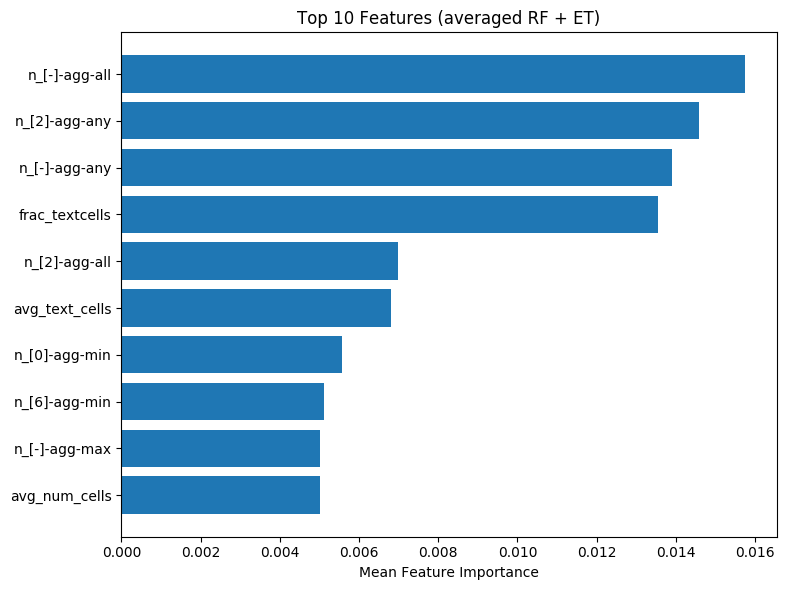

In [22]:
# 5) Plot
plt.figure(figsize=(8, 6))
plt.barh(imp_df['feature'].head(10)[::-1],
         imp_df['avg'].head(10)[::-1])
plt.xlabel("Mean Feature Importance")
plt.title("Top 10 Features (averaged RF + ET)")
plt.tight_layout()
plt.show()

### Predictions custom

In [35]:
data = pd.Series(
    [
        ["2024-02-30", "2020-03-01", "1982-12-30"],
        ["104805", "330956", "345609"],
        ["Male", "Female"],
        ["men", "women"],

    ],
    name="values"
)

In [36]:
data

0    [2024-02-30, 2020-03-01, 1982-12-30]
1                [104805, 330956, 345609]
2                          [Male, Female]
3                            [men, women]
Name: values, dtype: object

In [38]:
from sherlock.features.preprocessing import extract_features

extract_features(
    "../check.csv",
    data
)
feature_vectors = pd.read_csv("../check.csv", dtype=np.float32)

Extracting Features: 100%|██████████| 4/4 [00:00<00:00, 489.47it/s]

Exporting 1588 column features


In [39]:
feature_vectors

,n_[0]-agg-any,n_[0]-agg-all,n_[0]-agg-mean,n_[0]-agg-var,n_[0]-agg-min,n_[0]-agg-max,n_[0]-agg-median,n_[0]-agg-sum,n_[0]-agg-kurtosis,n_[0]-agg-skewness,...,par_vec_390,par_vec_391,par_vec_392,par_vec_393,par_vec_394,par_vec_395,par_vec_396,par_vec_397,par_vec_398,par_vec_399
0,1.0,1.0,2.666667,1.555556,1.0,4.0,3.0,8.0,-1.5,-0.381802,...,0.000482,-0.000699,0.000464,0.000695,0.000377,0.000414,-0.000623,-0.000379,-0.000771,-0.000442
1,1.0,1.0,1.333333,0.222222,1.0,2.0,1.0,4.0,-1.5,0.707107,...,0.000800,0.000959,0.000994,0.000532,0.000768,0.000870,-0.000838,-0.000695,0.000956,0.000615
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,-3.0,0.000000,...,-0.024608,-0.009890,-0.016155,0.000928,-0.008309,-0.015509,-0.020144,-0.037095,-0.001885,-0.040874
3,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,-3.0,0.000000,...,-0.072729,-0.022693,-0.110678,0.089974,-0.099107,-0.090429,-0.001951,-0.008750,0.021203,-0.082619


In [44]:
train_columns_means = pd.DataFrame(feature_vectors.mean()).transpose()
feature_vectors.fillna(train_columns_means.iloc[0], inplace=True)

In [45]:
model = rf_clf
#predicted_labels = model.predict(data)

# 1) Ensemble predictions on training set
y_pred_ensemble = voting_clf.predict(feature_vectors)

print(y_pred_ensemble)

# 2) RandomForest‐only predictions on training set
#y_pred_rf = rf_clf.predict(X_train)

['date_report' 'id' 'outcome' 'pre_existing_condition']
